# 1. Set up environment and libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style
plt.style.use('fivethirtyeight')
%matplotlib inline

# Random seed
np.random.seed(42)

# 2.
- Load data
- Calculate the correlations between numerical features and target variable
- Visualize the correlations between numerical features and target variable
- Visualize the visualize the distribution of the target variable
Note: target variable is 'cognitive performance score'

Dataset Dimensions: 100000 rows, 32 columns.

Correlation Coefficients (r) with Cognitive Performance Score:
stress_score                  -0.592584
work_hours_that_day           -0.345869
wake_episodes_per_night       -0.294673
shift_work                    -0.254351
alcohol_units_before_bed      -0.240015
sleep_latency_mins            -0.225244
heart_rate_resting_bpm        -0.090691
age                           -0.067792
caffeine_mg_before_bed        -0.065320
screen_time_before_bed_mins   -0.044216
bmi                           -0.037134
nap_duration_mins             -0.020294
room_temperature_celsius      -0.009311
weekend_sleep_diff_hrs        -0.003075
sleep_aid_used                 0.046867
steps_that_day                 0.135033
exercise_day                   0.254680
deep_sleep_percentage          0.280368
rem_percentage                 0.445967
felt_rested                    0.451526
sleep_duration_hrs             0.618241
sleep_quality_score            0.859978
Name: cogni

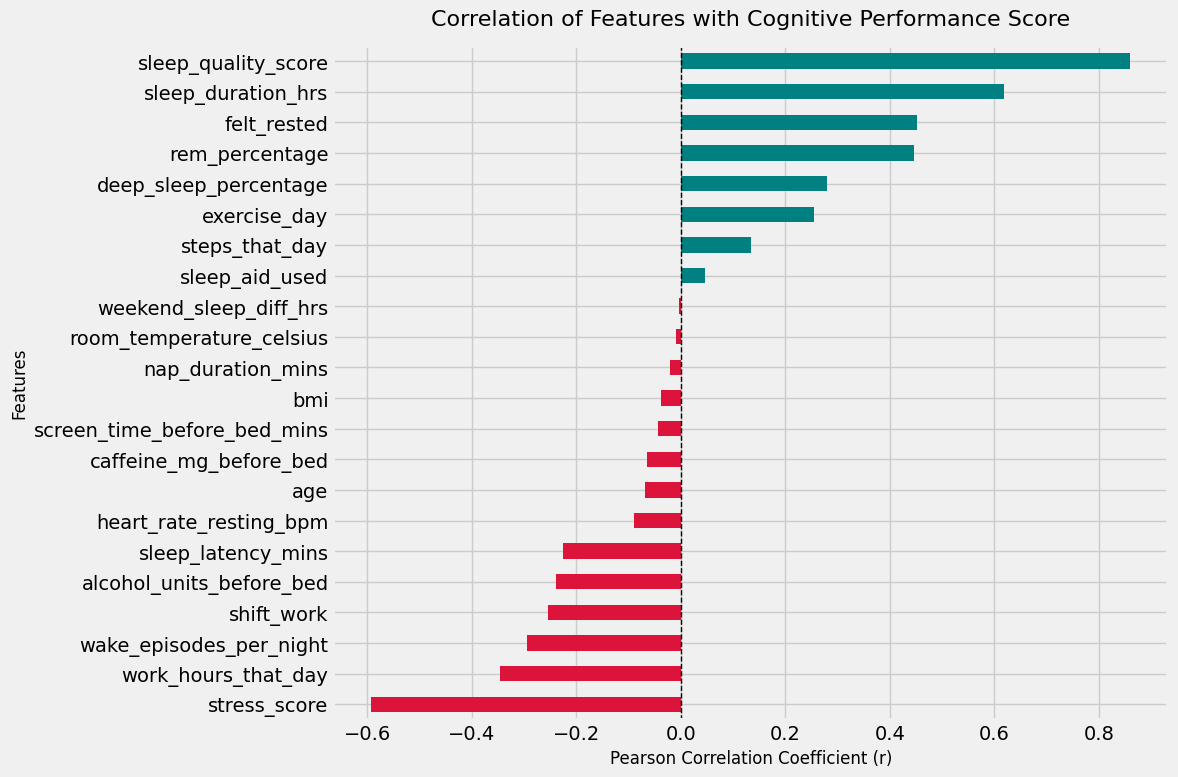

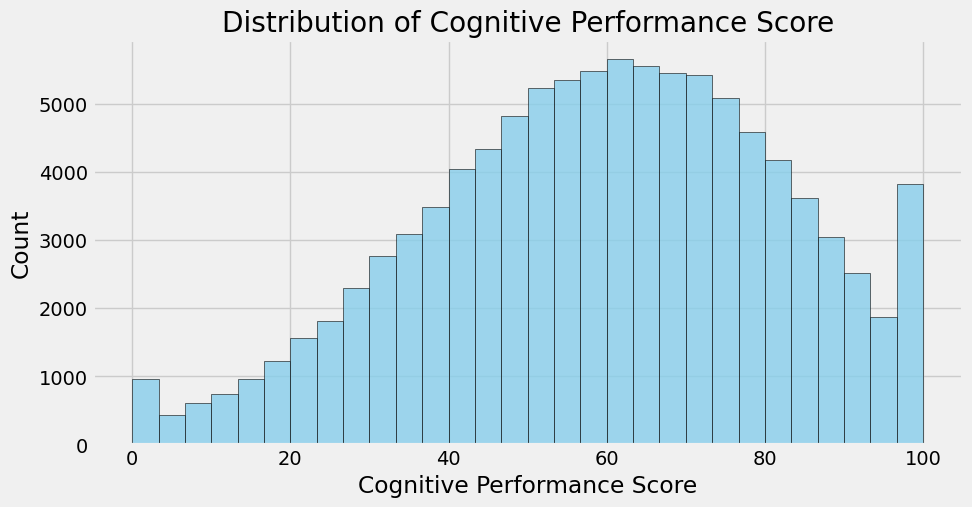

In [3]:
# Load dataset
df = pd.read_csv('sleep_health_dataset.csv')
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns.\n")

# Calculate the correlations for numerical features
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlations = numeric_df.corr()['cognitive_performance_score'].sort_values(ascending=False)
correlations = correlations.drop(['cognitive_performance_score', 'person_id'], errors='ignore').sort_values()
print("Correlation Coefficients (r) with Cognitive Performance Score:")
print(correlations)

# Plot 1: visualize the corelations for numerical features
plt.figure(figsize=(12, 8))
colors = ['crimson' if val < 0 else 'teal' for val in correlations.values]
correlations.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=1, linestyle='--')
plt.title('Correlation of Features with Cognitive Performance Score', fontsize=16, pad=15)
plt.xlabel('Pearson Correlation Coefficient (r)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

# Plot 2: visualize the distribution of the target variable
plt.figure(figsize=(10, 5))
plt.hist(df['cognitive_performance_score'], bins=30, edgecolor='black', color='skyblue', alpha=0.8)
plt.title('Distribution of Cognitive Performance Score')
plt.xlabel('Cognitive Performance Score')
plt.ylabel('Count')
plt.show()

*** Insight from plot 1 (correlation of features):
- core features:
    + sleep_quality_score (0.86)
    + sleep_duration_hrs (0.62)
    + stress_score (-0.59)
- valuable features:
    + felt_rested (0.45) & rem_percentage (0.45) & deep_sleep_percentage (0.28)
    + exercise_day (0.25)
    + work_hours_that_day (-0.35)
    + wake_episodes_per_night (-0.29)
    + shift_work (-0.25)
    + alcohol_units_before_bed (-0.24)
    + sleep_latency_mins (-0.23)
- Negligible features:
    + screen_time_before_bed_mins (-0.04)
    + caffeine_mg_before_bed (-0.06)
    + room_temperature_celsius (-0.009)
    + etc ...

*** Insight from plot 2 (distribution of target variable):
- Bell-shaped curve: a roughly normal distribution
    + Majority of people have an average level of cognitive performance score (around 60)
    + A decent number of people have a very high level of cognitive performance score (>= 95)

# 3. Simple linear regression for 2 factors with the strongest correlations to the cognitive performance score: 'sleep quality' and 'stress score'
   

Sleep Quality Equation: Cognitive Score = 12.70 * Sleep_Quality + -2.64
Stress Score Equation:  Cognitive Score = -8.14 * Stress_Score + 105.91



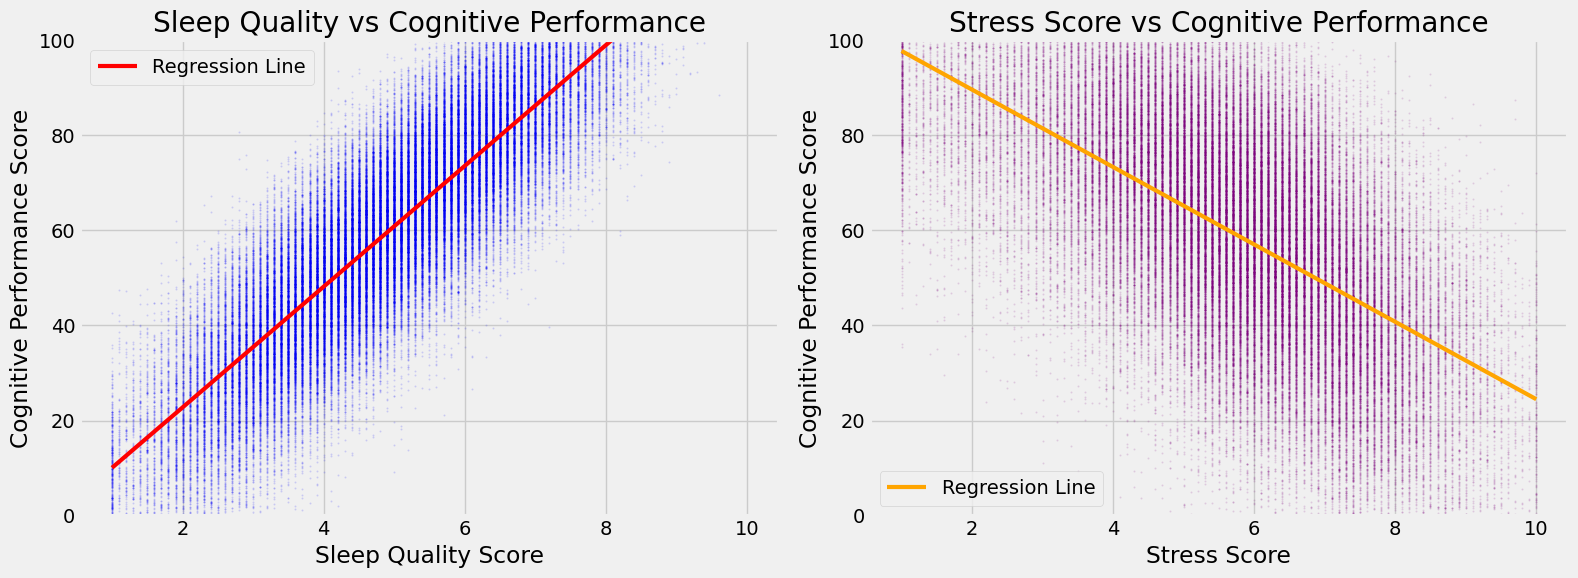

In [4]:
def standard_units(any_numbers):
    return (any_numbers - np.mean(any_numbers)) / np.std(any_numbers)

def correlation(t, x, y):
    return np.mean(standard_units(t[x]) * standard_units(t[y]))

def regression_parameters(t, x, y):
    r = correlation(t, x, y)
    slope = r * np.std(t[y]) / np.std(t[x])
    intercept = np.mean(t[y]) - slope * np.mean(t[x])
    return slope, intercept

# Calculate regression parameters
slope_sleep, intercept_sleep = regression_parameters(df, 'sleep_quality_score', 'cognitive_performance_score')
slope_stress, intercept_stress = regression_parameters(df, 'stress_score', 'cognitive_performance_score')

print(f"Sleep Quality Equation: Cognitive Score = {slope_sleep:.2f} * Sleep_Quality + {intercept_sleep:.2f}")
print(f"Stress Score Equation:  Cognitive Score = {slope_stress:.2f} * Stress_Score + {intercept_stress:.2f}\n")

# Plot the two regression lines
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Sleep Quality vs Cognitive Performance
ax1.scatter(df['sleep_quality_score'], df['cognitive_performance_score'], color='blue', alpha=0.1, s=1)
x_vals_sleep = np.array([df['sleep_quality_score'].min(), df['sleep_quality_score'].max()])
y_vals_sleep = slope_sleep * x_vals_sleep + intercept_sleep
ax1.plot(x_vals_sleep, y_vals_sleep, color='red', lw=3, label='Regression Line')
ax1.set_title('Sleep Quality vs Cognitive Performance')
ax1.set_xlabel('Sleep Quality Score')
ax1.set_ylabel('Cognitive Performance Score')
ax1.set_ylim(0, 100)
ax1.legend()

# Plot 2: Stress Score vs Cognitive Performance
ax2.scatter(df['stress_score'], df['cognitive_performance_score'], color='purple', alpha=0.1, s=1)
x_vals_stress = np.array([df['stress_score'].min(), df['stress_score'].max()])
y_vals_stress = slope_stress * x_vals_stress + intercept_stress
ax2.plot(x_vals_stress, y_vals_stress, color='orange', lw=3, label='Regression Line')
ax2.set_title('Stress Score vs Cognitive Performance')
ax2.set_xlabel('Stress Score')
ax2.set_ylabel('Cognitive Performance Score')
ax2.set_ylim(0, 100)
ax2.legend()

plt.tight_layout()
plt.show()

*** Insight from left plot (sleep quality vs cognitive performance):
- relationship: strong positive linear association
- with slope value of 12.7, a steep upward-sloping regression line confirms that higher sleep quality predicts higher cognitive performance

*** Insight from right plot (stress score vs cognitive performance):
- relationship: strong negative linear association
- with slope value of -8.14, a distinct downward-sloping regression line highlights that higher stress levels systematically impair cognitive scores

# 4. How each sleep-related features affect cognitive performance score

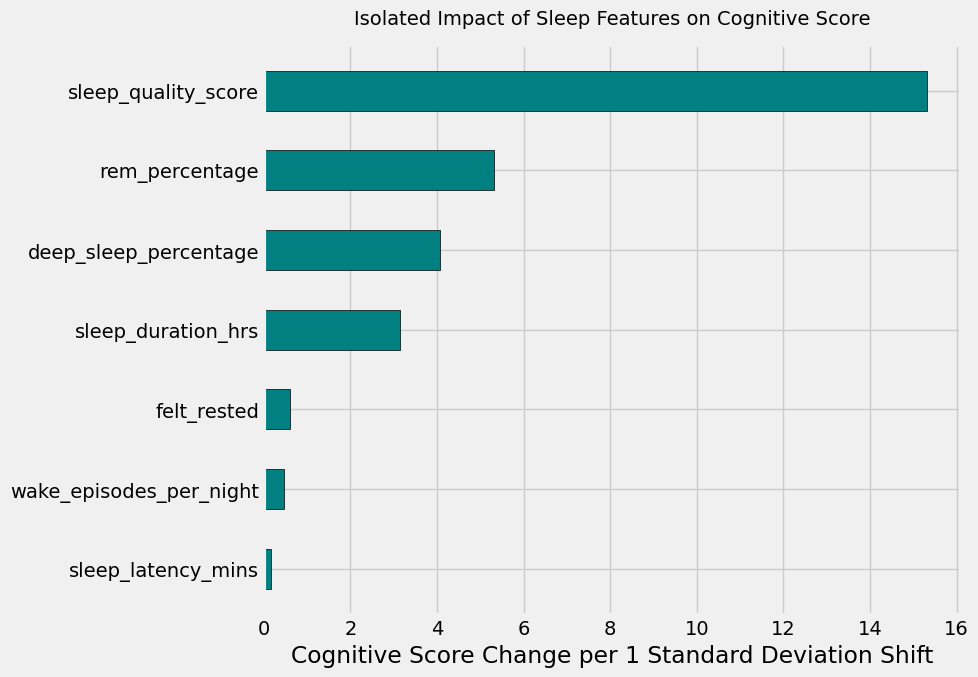

In [5]:
# Select all sleep-related features
sleep_features = [
    'sleep_duration_hrs',
    'sleep_quality_score',
    'felt_rested',
    'rem_percentage',
    'deep_sleep_percentage',
    'sleep_latency_mins',
    'wake_episodes_per_night'
]
target = 'cognitive_performance_score'

# Clean data
clean_df = df[sleep_features + [target]].dropna()
X = clean_df[sleep_features]
y = clean_df[target]

# Standardize
X_scaled = (X - X.mean()) / X.std()

# Isolate the unique impact of each feature
X_matrix = np.column_stack([np.ones(X_scaled.shape[0]), X_scaled.values])
y_matrix = y.values
beta_weights = np.linalg.inv(X_matrix.T @ X_matrix) @ X_matrix.T @ y_matrix
isolated_impacts = beta_weights[1:]

results_df = pd.DataFrame({
    'Sleep Feature': sleep_features,
    'Isolated Weight': isolated_impacts
}).sort_values(by='Isolated Weight')

# Plot the data
plt.style.use('fivethirtyeight')
plt.figure(figsize=(10, 7))
colors = ['crimson' if val < 0 else 'teal' for val in results_df['Isolated Weight']]
plt.barh(results_df['Sleep Feature'], results_df['Isolated Weight'], color=colors, edgecolor='black', height=0.5)
plt.axvline(0, color='black', linewidth=1.5, linestyle='--')
plt.title('Isolated Impact of Sleep Features on Cognitive Score', fontsize=14, pad=15)
plt.xlabel('Cognitive Score Change per 1 Standard Deviation Shift')
plt.tight_layout()
plt.show()

*** Insight:
- sleep_quality_score vs sleep_duration_hrs:
    + sleep_quality_score has a massive weight of roughly 15.4, while sleep_duration_hrs sits at only 3.2
    + sleep quality is roughly 5 times more important for next-day cognitive performance than the actual number of hours spent in bed. Adding an extra hour of low-quality sleep will do almost nothing for your brain compared to making sure the sleep you get is deep and restful
- The Power duo of Sleep Architecture (REM & Deep Sleep):
    + rem_percentage has a score of 5.3, and deep_sleep_percentage has a score of roughly 4.1
    + both components of your natural sleep cycle matter significantly more than raw sleep duration (3.2)
    + This proves that biological brain recovery (REM for memory processing and Deep Sleep for physical/cognitive repair) is the real engine behind your performance. Getting into these high-value sleep stages matters more than the number of sleep hours
- felt_rested:
    + felt_rested has a score of 0.6
    + felt_rested does not bring any new information to the table. if sleep quality score is already known, tracking whether you feel rested or not adds almost no extra value to predicting you cognitive performance
- wake_episodes_per_night:
    + wake_episodes_per_night has a score of 0.5
    + This means that briefly waking up a few times does not independently damage your brain power, provided that your overall sleep quality, REM, and deep sleep percentages manage to stay high.
- sleep_latency_mins:
    + sleep_latency_mins has a negligible score of roughly 0.15, pinning it at the absolute bottom of the chart
    + This reveals that how long it takes you to fall asleep has zero independent impact on your cognitive performance the next day
- Summary:
    + prioritize: deep, uninterrupted sleep quality over how many hours of sleep
    + optimize: focus on factors that increase REM sleep cycles

# 5. How daily work hours affect cognitive performance

Pearson Correlation Coefficient: -0.3459
Intercept (Baseline Score): 74.99
Slope (Point change per 1 additional work hour): -2.2095


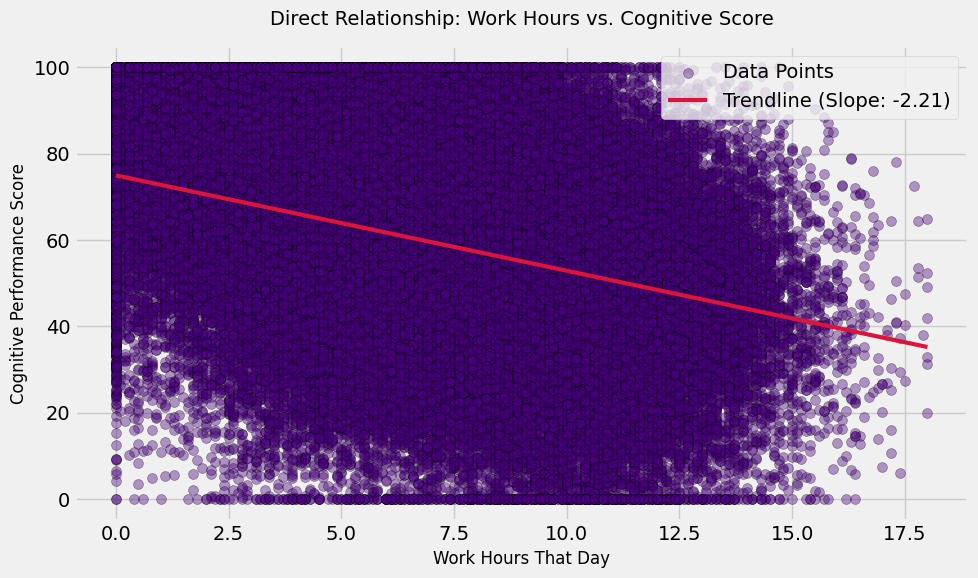

In [6]:
feature = 'work_hours_that_day'
target = 'cognitive_performance_score'

# Clean data
clean_df = df[[feature, target]].dropna()
X = clean_df[feature].values
y = clean_df[target].values

#Calculate the Pearson Correlation Coefficient
correlation = np.corrcoef(X, y)[0, 1]
print(f"Pearson Correlation Coefficient: {correlation:.4f}")

# 2. Use OLS to find the line of best fit
X_matrix = np.column_stack([np.ones(len(X)), X])
beta_weights = np.linalg.inv(X_matrix.T @ X_matrix) @ X_matrix.T @ y
intercept, slope = beta_weights[0], beta_weights[1]

print(f"Intercept (Baseline Score): {intercept:.2f}")
print(f"Slope (Point change per 1 additional work hour): {slope:.4f}")

# Plot the relationship
plt.style.use('fivethirtyeight')
plt.figure(figsize=(10, 6))

# Scatter plot of the raw data points
plt.scatter(X, y, color='indigo', alpha=0.4, edgecolor='black', s=50, label='Data Points')

# Draw the OLS trendline
x_trend = np.linspace(X.min(), X.max(), 100)
y_trend = intercept + slope * x_trend
plt.plot(x_trend, y_trend, color='crimson', linewidth=3, label=f'Trendline (Slope: {slope:.2f})')
plt.title('Direct Relationship: Work Hours vs. Cognitive Score', fontsize=14, pad=15)
plt.xlabel('Work Hours That Day', fontsize=12)
plt.ylabel('Cognitive Performance Score', fontsize=12)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

*** insight:
- The trendline shows a negative slope of -2.21
- This means every hour people spend working chips away your cognitive performance capacity for the next day. For every additional hour, people take a predictable -2.21 point hit to their cognitive score

# 6. Whether the difference in cognitive performance scores between regular workers and shift workers is significant or simply a result of random choice ?

Observed Difference in Reality: 20.3556

Empirical P-value from 2000 simulations: 0.0


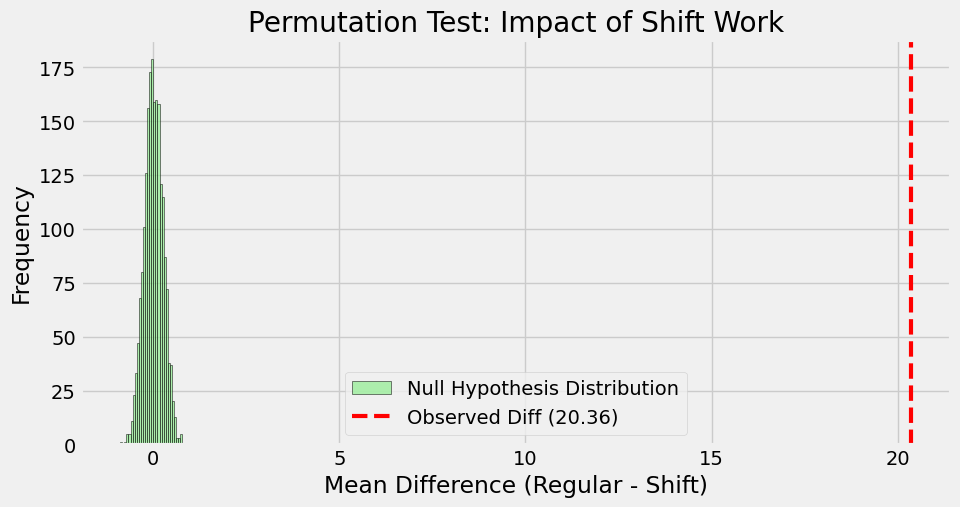

In [7]:
# Extract the scores for 2 groups: 'regular work' and 'shift work'
regular_work = df[df['shift_work'] == 0]['cognitive_performance_score'].values
shift_work = df[df['shift_work'] == 1]['cognitive_performance_score'].values

observed_diff = np.mean(regular_work) - np.mean(shift_work)
print(f"Observed Difference in Reality: {observed_diff:.4f}\n")

# Perform a Permutation Test (2,000 random shuffles)
all_scores = df['cognitive_performance_score'].values
n_regular = len(regular_work)
simulated_diffs = []
repetitions = 2000

for i in range(repetitions):
    shuffled = np.random.permutation(all_scores)
    sim_diff = np.mean(shuffled[:n_regular]) - np.mean(shuffled[n_regular:])
    simulated_diffs.append(sim_diff)

# Compute P-value
p_value = np.count_nonzero(np.array(simulated_diffs) >= observed_diff) / repetitions
print(f"Empirical P-value from {repetitions} simulations: {p_value}")

# Plot the distribution under the Null Hypothesis vs the Observed Difference
plt.figure(figsize=(10, 5))
plt.hist(simulated_diffs, bins=30, edgecolor='black', color='lightgreen', alpha=0.7, label='Null Hypothesis Distribution')
plt.axvline(observed_diff, color='red', linestyle='dashed', linewidth=3, label=f'Observed Diff ({observed_diff:.2f})')
plt.title('Permutation Test: Impact of Shift Work')
plt.xlabel('Mean Difference (Regular - Shift)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

*** Insight:
- Shift Work Carries a Massive Cognitive Penalty:
    + The Data: The red dashed line shows an observed difference of 20.36 points in favor of regular-hours workers
    + The Insight: In real life, people working regular schedules score over 20 points higher on the cognitive performance test than those working shift schedules
- The empirical p-value is 0.0 after 2,000 random shuffles. This means shift work has zero effect on your brain, and any differences are just random luck.

# 7. Impact of physical activity (steps & exercise) on cognitive score

--- Steps That Day Analysis ---
Pearson Correlation: 0.1350
Slope: 0.0009

--- Exercise Day Analysis ---
Pearson Correlation: 0.2547
Mean Score (No Exercise): 54.09
Mean Score (Exercised): 65.48
Difference: 11.39 points



C:\Users\Fawlkin\AppData\Local\Temp\ipykernel_18104\1006928169.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Exercise (0)', 'Exercised (1)'])


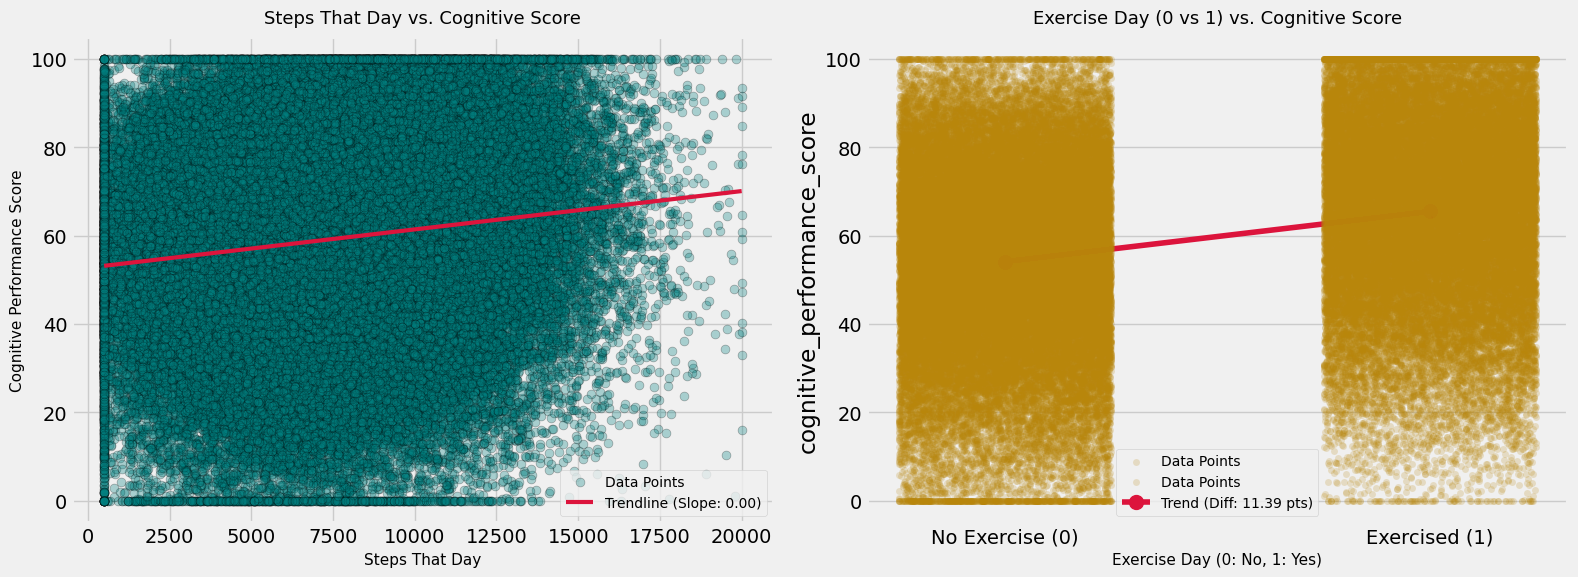

In [11]:
activity_features = ['steps_that_day', 'exercise_day']
target = 'cognitive_performance_score'

clean_df = df[activity_features + [target]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: steps that day
ax = axes[0]
X1 = clean_df['steps_that_day'].values
y1 = clean_df[target].values

correlation1 = np.corrcoef(X1, y1)[0, 1]
X_matrix1 = np.column_stack([np.ones(len(X1)), X1])
beta1 = np.linalg.inv(X_matrix1.T @ X_matrix1) @ X_matrix1.T @ y1

ax.scatter(X1, y1, color='teal', alpha=0.3, edgecolor='black', s=40, label='Data Points')

x_trend1 = np.linspace(X1.min(), X1.max(), 100)
ax.plot(x_trend1, beta1[0] + beta1[1] * x_trend1, color='crimson', linewidth=3, label=f'Trendline (Slope: {beta1[1]:.2f})')

ax.set_title('Steps That Day vs. Cognitive Score', fontsize=13, pad=10)
ax.set_xlabel('Steps That Day', fontsize=11)
ax.set_ylabel('Cognitive Performance Score', fontsize=11)
ax.legend(loc='best', fontsize=10)

print(f"--- Steps That Day Analysis ---")
print(f"Pearson Correlation: {correlation1:.4f}")
print(f"Slope: {beta1[1]:.4f}\n")


# Plot 2: exercise day (binary variable)
ax = axes[1]
X2 = clean_df['exercise_day'].values
y2 = clean_df[target].values

correlation2 = np.corrcoef(X2, y2)[0, 1]

# Use Stripplot with jitter=True to spread out the 0 and 1 points horizontally
sns.stripplot(x='exercise_day', y=target, data=clean_df, ax=ax,
              color='darkgoldenrod', alpha=0.2, size=5, jitter=0.25, label='Data Points')

mean_0 = clean_df[clean_df['exercise_day'] == 0][target].mean()
mean_1 = clean_df[clean_df['exercise_day'] == 1][target].mean()
ax.plot([0, 1], [mean_0, mean_1], color='crimson', marker='o', markersize=10, 
        linewidth=4, label=f'Trend (Diff: {mean_1 - mean_0:.2f} pts)')

ax.set_title('Exercise Day (0 vs 1) vs. Cognitive Score', fontsize=13, pad=10)
ax.set_xlabel('Exercise Day (0: No, 1: Yes)', fontsize=11)
ax.set_xticklabels(['No Exercise (0)', 'Exercised (1)'])
ax.legend(loc='best', fontsize=10)

print(f"--- Exercise Day Analysis ---")
print(f"Pearson Correlation: {correlation2:.4f}")
print(f"Mean Score (No Exercise): {mean_0:.2f}")
print(f"Mean Score (Exercised): {mean_1:.2f}")
print(f"Difference: {mean_1 - mean_0:.2f} points\n")

plt.tight_layout()
plt.show()

*** Insight:
- Intentional Exercise Provides a Massive jump:
    + The exercise_day analysis reveals a correlation of 0.2547 and a powerful slope of 11.39
    + Simply working out rewards your brain with an immediate 11.39-point boost to your cognitive performance the next day. This is a massive leverage point, counteracting nearly all of the cognitive drain caused by a grueling 12-hour workday.
- Steps Matter, But You Need High Volume to See the true result:
    + The slope for steps_that_day is 0.0009 points per step. Because the value per step is small, the trendline on the plot rounds to 0.0
    + If people increase daily movement from a sedentary 3,000 steps to an active 13,000 steps, that accumulation delivers an extra 9.0 points of cognitive performance. Passive movement adds up, but it requires serious consistency to match the impact of a focused workout.

# 8. How alcohol consumption before bed affect cognitive performance using bootstrap

95% Confidence Interval for the mean cognitive score of the alcohol group: [44.64, 45.60]



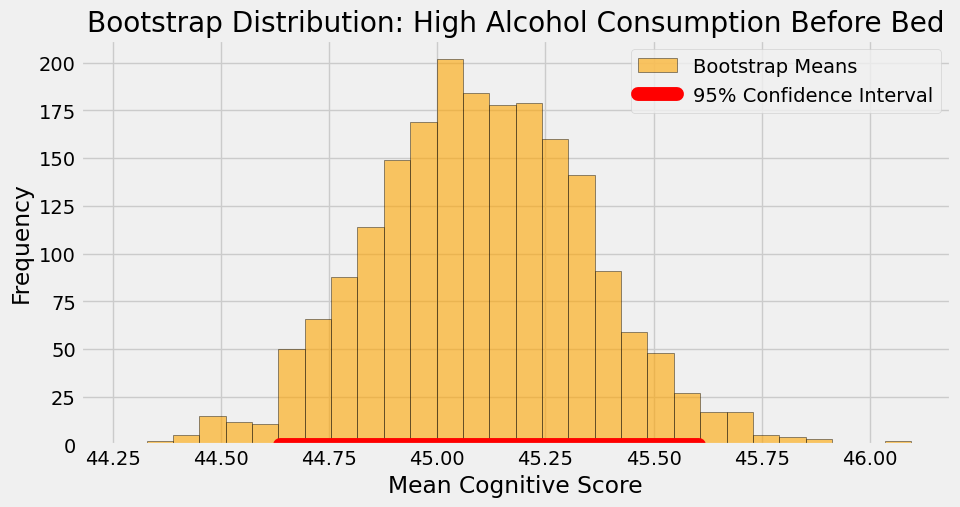

In [ ]:
# Filter the group with high alcohol consumption before bed (> 2 units)
alcohol_group = df[df['alcohol_units_before_bed'] > 2]['cognitive_performance_score'].values
n_alcohol = len(alcohol_group)

# Perform Bootstrapping
bootstrap_means = []
for i in range(2000):
    resample = np.random.choice(alcohol_group, size=n_alcohol, replace=True)
    bootstrap_means.append(np.mean(resample))

# Determine the 95% Confidence Interval by finding the 2.5th and 97.5th percentiles
ci_lower = np.percentile(bootstrap_means, 2.5)
ci_upper = np.percentile(bootstrap_means, 97.5)
print(f"95% Confidence Interval for the mean cognitive score of the alcohol group: [{ci_lower:.2f}, {ci_upper:.2f}]\n")

# Plot Bootstrapping distribution and Confidence Interval
plt.figure(figsize=(10, 5))
plt.hist(bootstrap_means, bins=30, edgecolor='black', color='orange', alpha=0.6, label='Bootstrap Means')
plt.plot([ci_lower, ci_upper], [0, 0], color='red', lw=10, solid_capstyle='round', label='95% Confidence Interval')
plt.title('Bootstrap Distribution: High Alcohol Consumption Before Bed')
plt.xlabel('Mean Cognitive Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()

*** Insight:
- The cognitive baseline is heavily suppressed
    + The distribution centerrs right around a mean score of 45.05
    + Having more than two drinks before bed forces a strict, low limit on your brain power the next day. It basically traps your mental sharpness at a low level, meaning no amount of coffee or effort can help your brain break through and reach its full potential tomorrow.
- The red bar at the bottom shows a 95% confidence interval spanning tightly from roughly 44.62 to 45.62
- This means if we expand this case study, we can be 95% confident that the true population avg for before-bed alcohol consumers would still land within this exact window